# Clustering on Synthetic Data
All clustering algorithms and evaluation metrics in this work were implemented using the [scikit-learn](https://scikit-learn.org/stable/modules/clustering.html) machine learning library.

In [1]:
# Suppress all warnings by overriding the default warnings.warn function

def warn(*args, **kwargs): 
    pass 
import warnings 
warnings.warn = warn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [3]:
data = pd.read_csv('./Data/k_means_data.csv')
centroid = pd.read_csv('./Data/k_means_centroid.csv')

df = data[['feature1','feature2']]

# 1. K Means 

In [4]:
# Function to perform K-Means clustering on a dataset
# Returns cluster labels, cluster centers, inertia, and number of iterations

def k_means_func(data, k, algor='lloyd', init_cluster= 'k-means++', random_seed=6020):
    kmeans = KMeans(n_clusters=k, algorithm=algor, init=init_cluster,random_state=random_seed, max_iter=1000)
    cluster_labels = kmeans.fit_predict(data)
    centers = kmeans.cluster_centers_
    step = kmeans.n_iter_
    inertia=kmeans.inertia_
    return cluster_labels, centers, inertia, step

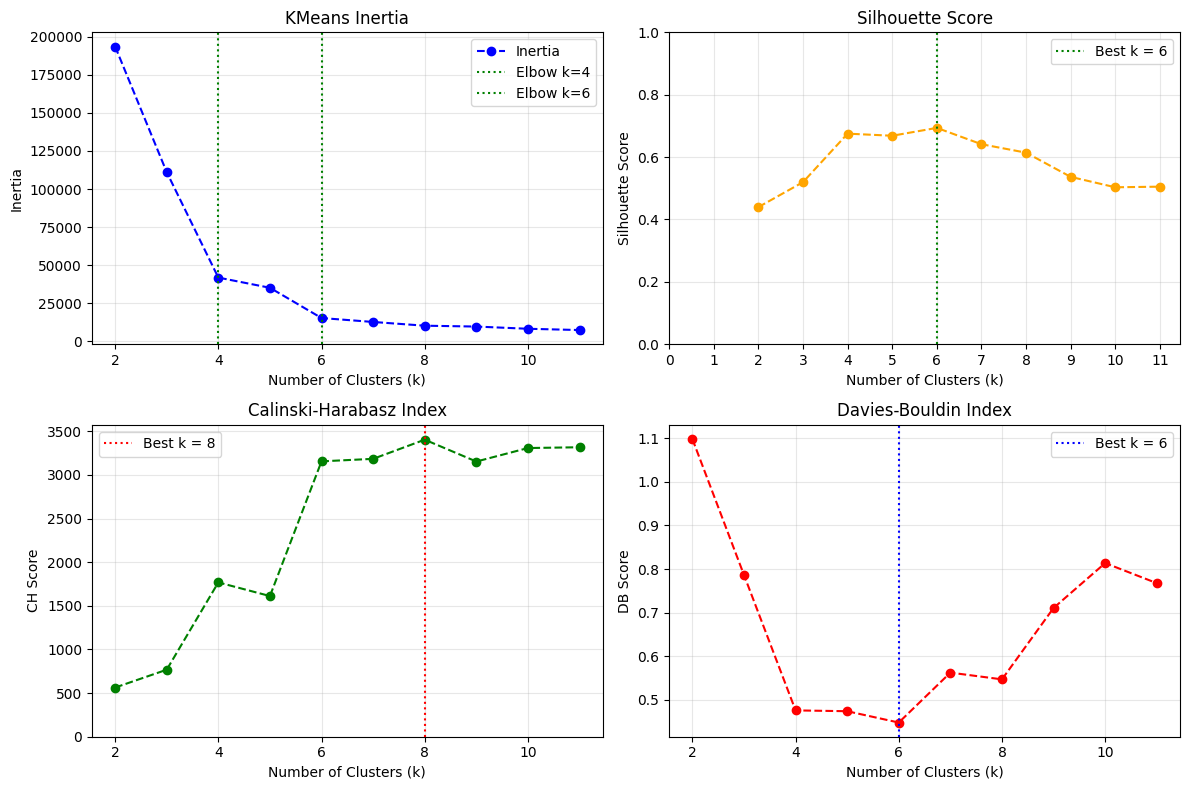

In [5]:
# Source [3]
def cluster_metric_for_k(data_set, max_k=11):
    k_values = range(2, max_k + 1)
    inertia, silh_score, ch_score, db_score = [], [], [], []

    for k in k_values:
        cluster_labels, _, k_inertia, _ = k_means_func(data_set, k)
        inertia.append(k_inertia)
        silh_score.append(silhouette_score(data_set, cluster_labels))
        ch_score.append(calinski_harabasz_score(data_set, cluster_labels))
        db_score.append(davies_bouldin_score(data_set, cluster_labels))

    # To find best value for k
    best_silh_k = k_values[silh_score.index(max(silh_score))]
    best_ch_k   = k_values[ch_score.index(max(ch_score))]
    best_db_k   = k_values[db_score.index(min(db_score))]

    fig, ax = plt.subplots(2, 2, figsize=(12, 8))

    # 1. Inertia
    ax1 = ax[0, 0]
    ax1.plot(k_values, inertia, marker="o", linestyle="--", color="blue")
    ax1.set_title("KMeans Inertia")
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Inertia")
    ax1.grid(True, alpha=0.3)
    ax1.axvline(x=4, color='green', linestyle=':')
    ax1.axvline(x=6, color='green', linestyle=':')
    ax1.legend(["Inertia", "Elbow k=4", "Elbow k=6"])

    # 2. Silhouette
    ax2 = ax[0, 1]
    ax2.plot(k_values, silh_score, marker='o', linestyle='--', color='orange')
    ax2.set_title("Silhouette Score")
    ax2.set_xlabel("Number of Clusters (k)")
    ax2.set_ylabel("Silhouette Score")
    ax2.set_xticks(range(max_k + 1))
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(best_silh_k, color='green', linestyle=':', label=f"Best k = {best_silh_k}")
    ax2.legend()

    # 3. Calinski–Harabasz
    ax3 = ax[1, 0]
    ax3.plot(k_values, ch_score, marker='o', linestyle='--', color='green')
    ax3.set_title("Calinski-Harabasz Index")
    ax3.set_xlabel("Number of Clusters (k)")
    ax3.set_ylabel("CH Score")
    ax3.set_ylim(0, max(ch_score) * 1.05)
    ax3.grid(True, alpha=0.3)
    ax3.axvline(best_ch_k, color='red', linestyle=':', label=f"Best k = {best_ch_k}")
    ax3.legend()

    #  4. Davies–Bouldin
    ax4 = ax[1, 1]
    ax4.plot(k_values, db_score, marker='o', linestyle='--', color='red')
    ax4.set_title("Davies-Bouldin Index")
    ax4.set_xlabel("Number of Clusters (k)")
    ax4.set_ylabel("DB Score")
    ax4.grid(True, alpha=0.3)
    ax4.axvline(best_db_k, color='blue', linestyle=':', label=f"Best k = {best_db_k}")
    ax4.legend()

    plt.tight_layout()
    plt.savefig("../images/synthetic_data/kmeans_optimal_k_metrics.png", dpi=300)
    plt.show()
cluster_metric_for_k(df)

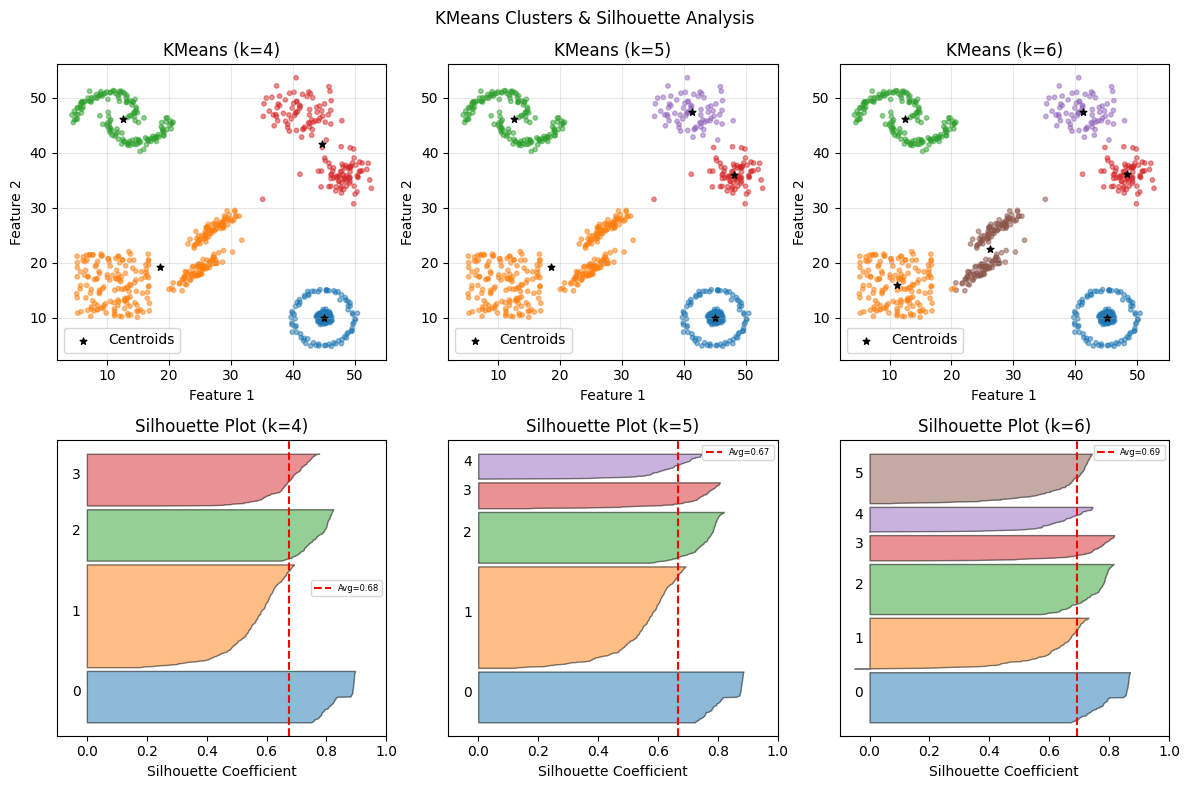

In [6]:
# Source [1]

def combined_kmeans_silhouette(data, k_values):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.reshape(2, 3)

    for i, k in enumerate(k_values):

        cluster_labels, centers, _, _ = k_means_func(data, k)

        silhouette_avg = silhouette_score(data, cluster_labels)
        sample_silhouette_values = silhouette_samples(data, cluster_labels)

        colors = np.array(plt.cm.tab10.colors[:k])
        point_colors = colors[cluster_labels] 

        ax1 = axes[0, i]
        ax1.scatter(data.iloc[:,0], data.iloc[:,1], color=point_colors, s=10, alpha=0.5)
        ax1.scatter(centers[:,0], centers[:,1], c='black', marker='*', s=25, label='Centroids')
        ax1.set_title(f"KMeans (k={k})")
        ax1.set_xlabel("Feature 1")
        ax1.set_ylabel("Feature 2")
        ax1.legend(loc='lower left')
        ax1.grid(alpha=0.3)

        ax2 = axes[1, i]
        y_lower = 10
        for j in range(k): 
            mask = cluster_labels == j
            sil_vals = sample_silhouette_values[mask]
            sil_vals.sort()
            size = sil_vals.shape[0]
            y_upper = y_lower + size
            ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals, facecolor=colors[j], edgecolor='black', alpha=0.5)
            ax2.text(-0.05, y_lower + 0.5*size, str(j))
            y_lower = y_upper + 10

        ax2.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Avg={silhouette_avg:.2f}")
        ax2.set_title(f"Silhouette Plot (k={k})")
        ax2.set_xlabel("Silhouette Coefficient")
        ax2.set_yticks([])
        ax2.set_xlim([-0.1, 1])
        ax2.legend(fontsize=6)

    fig.suptitle("KMeans Clusters & Silhouette Analysis")
    plt.tight_layout()
    plt.savefig("../images/synthetic_data/kmeans_clusters_silhouette.png", dpi=300)
    plt.show()
    
combined_kmeans_silhouette(df, [4,5,6])

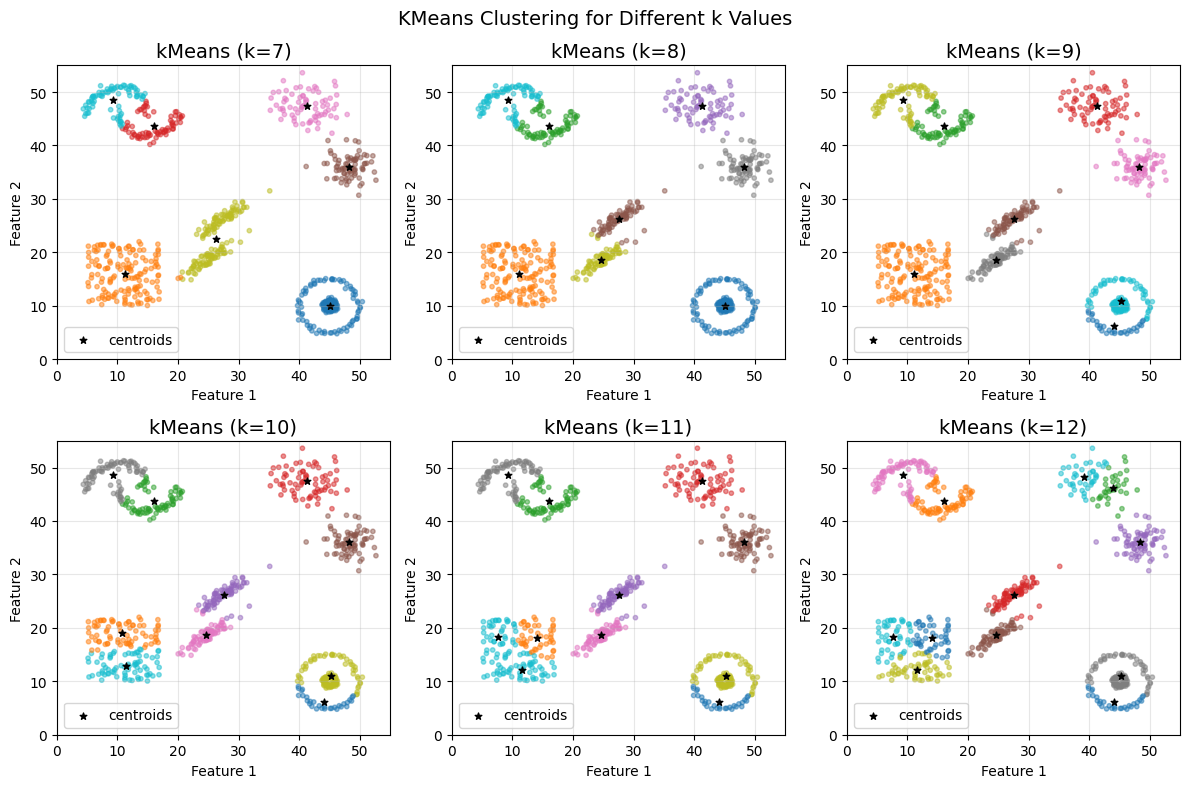

In [7]:
def k_graph(data, k_values):
    fig, axes = plt.subplots(2, 3, figsize=(12,8))  
    axes = axes.ravel() 

    for i, k in enumerate(k_values):

        cluster_labels, centers, _, _ = k_means_func(data, k)

        ax = axes[i]  
        ax.scatter(data.iloc[:,0], data.iloc[:,1], s=10, alpha=0.5, c=cluster_labels, cmap='tab10')
        ax.scatter(centers[:,0], centers[:,1], c='black', marker='*', s=25, label='centroids')
        ax.set_title(f"kMeans (k={k})", fontsize=14)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.set_xlim(0,55)
        ax.set_ylim(0,55)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='lower left')

    plt.suptitle("KMeans Clustering for Different k Values", fontsize=14)
    plt.tight_layout()
    plt.savefig("../images/synthetic_data/kmeans_clusters_various_k.png", dpi=300)
    plt.show()

k_graph(df, [7,8,9,10,11,12])

Stability check for K=6
--------------------------------------------------
Seed=1      Inertia=15284.10    Silhouette=0.694     Iter=4
Seed=6      Inertia=19392.19    Silhouette=0.635     Iter=5
Seed=60     Inertia=15283.79    Silhouette=0.694     Iter=4
Seed=602    Inertia=34647.11    Silhouette=0.577     Iter=3
Seed=620    Inertia=19392.19    Silhouette=0.635     Iter=8
Seed=6020   Inertia=15283.79    Silhouette=0.694     Iter=4


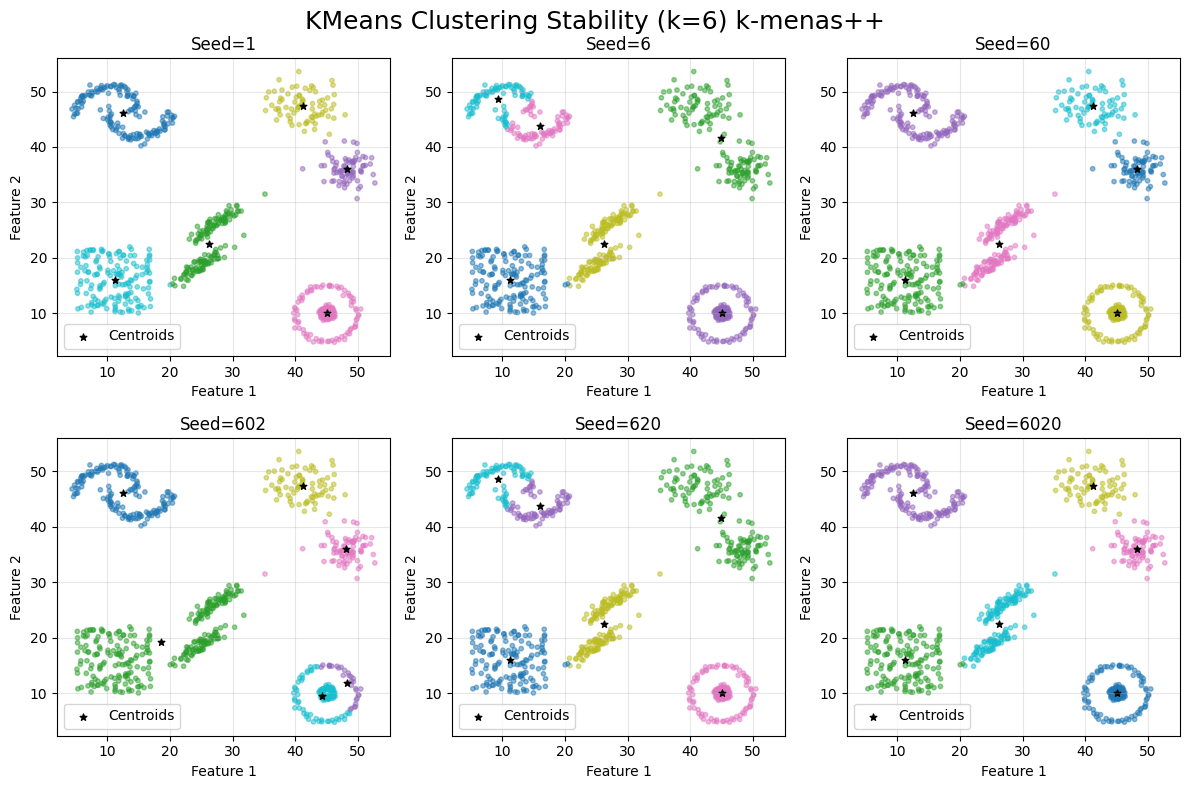

In [8]:
#Spource [2]
def k_stability_grid(data, best_k=6, seeds=[1, 6, 60, 602, 620, 6020], init_clus= 'k-means++', title=" "):

    print(f"Stability check for K={best_k}")
    print("-"*50)

    results = []

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()  # flatten 2x3 grid

    for i, seed in enumerate(seeds):
        labels, centers, inertia, steps = k_means_func(data, best_k, algor='lloyd',init_cluster= init_clus, random_seed=seed)
        silh = silhouette_score(data, labels)
        results.append((seed, inertia, silh, steps))
        print(f"Seed={seed:<5}  Inertia={inertia:<10.2f}  Silhouette={silh:<8.3f}  Iter={steps}")

        ax = axes[i]
        # Scatter points colored by cluster
        ax.scatter(data.iloc[:,0], data.iloc[:,1], c=labels, cmap='tab10', s=10, alpha=0.5)
        # Scatter centroids
        ax.scatter(centers[:,0], centers[:,1], c='black', marker='*', s=25, label='Centroids')
        ax.set_title(f"Seed={seed}", fontsize=12)
        ax.set_xlabel("Feature 1", fontsize=10)
        ax.set_ylabel("Feature 2", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='lower left')
    
    fig.suptitle(f"KMeans Clustering Stability (k={best_k}) {title}", fontsize=18)
    plt.tight_layout()
    plt.savefig(f"../images/synthetic_data/kmeans_stability_initialization_{title}.png", dpi=300)
    plt.subplots_adjust(top=0.92)
    plt.show()

    return results

stability_results = k_stability_grid(df, best_k=6, title='k-menas++')

Stability check for K=6
--------------------------------------------------
Seed=1      Inertia=15283.79    Silhouette=0.694     Iter=3
Seed=6      Inertia=15283.79    Silhouette=0.694     Iter=3
Seed=60     Inertia=15284.10    Silhouette=0.694     Iter=5
Seed=602    Inertia=15283.79    Silhouette=0.694     Iter=8
Seed=620    Inertia=19392.19    Silhouette=0.635     Iter=10
Seed=6020   Inertia=15283.79    Silhouette=0.694     Iter=5


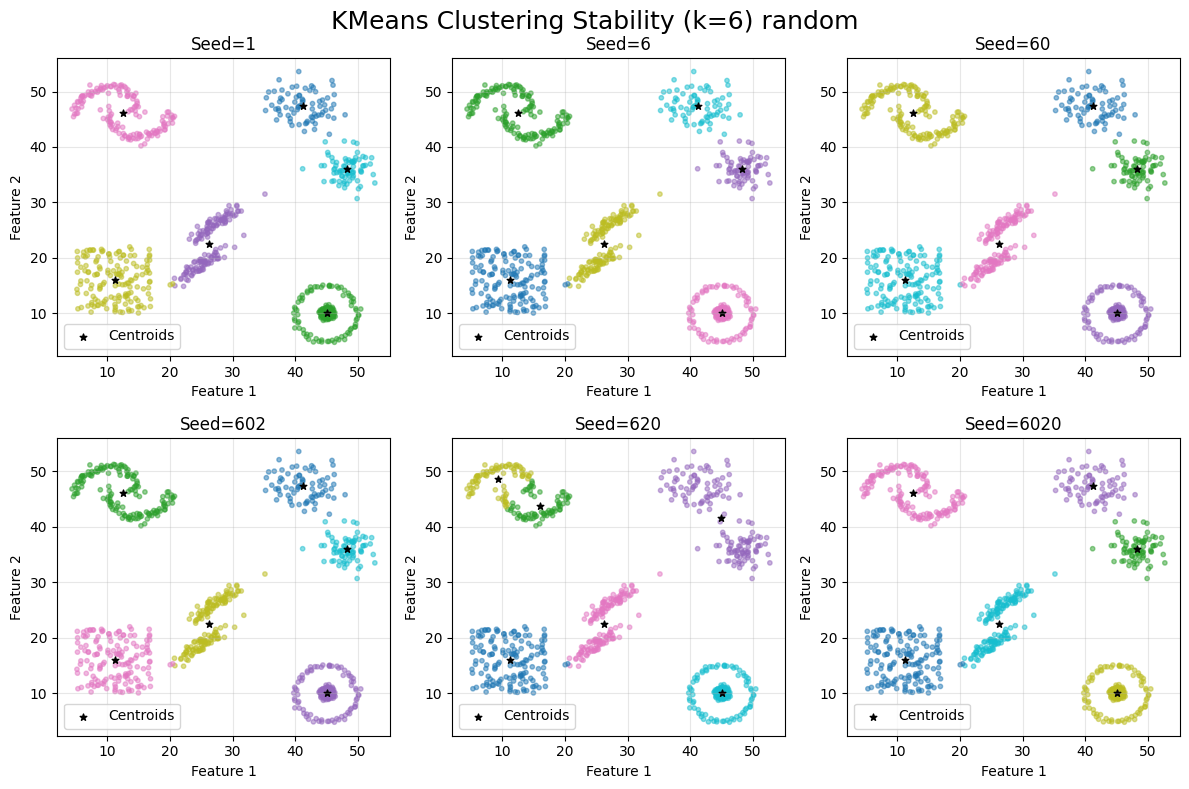

In [9]:
stability_results = k_stability_grid(df, best_k=6, init_clus= 'random' , title='random')

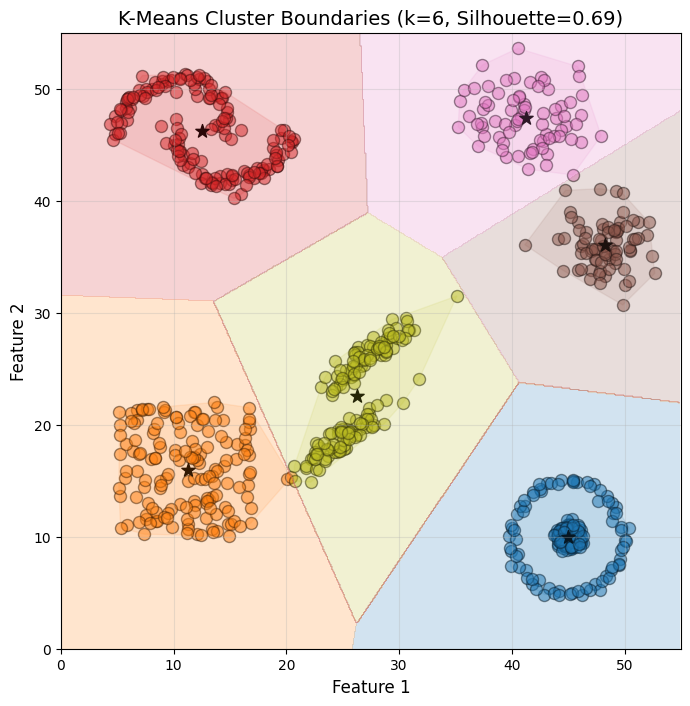

In [12]:
## https://numpy.org/devdocs/reference/generated/numpy.meshgrid.html
## https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html#matplotlib.pyplot.contourf
## https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.ConvexHull.html

from scipy.spatial import ConvexHull
from matplotlib.colors import ListedColormap

def voronoi_graph(data_set,k=6):
    
    kmeans = KMeans(n_clusters=k, random_state=6020, max_iter=1000, n_init=10)
    cluster_labels = kmeans.fit_predict(data_set)
    centers=kmeans.cluster_centers_
    sil_score=silhouette_score(data_set, cluster_labels)

    h = 0.1
    x_min, x_max = 0, 55
    y_min, y_max = 0, 55

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cmap = plt.cm.tab10
    colors = [cmap(i / k) for i in range(k)]  
    cmap_bg = ListedColormap(colors)

    plt.figure(figsize=(8,8))
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    for i, color in enumerate(colors):
        cluster_points = data_set[cluster_labels==i]
        plt.scatter(cluster_points['feature1'], cluster_points['feature2'], s=75 ,
                    color=color, edgecolor='black', alpha = 0.5, label=f'Cluster {i}')

        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points.values)
            plt.fill(cluster_points.values[hull.vertices,0],
                    cluster_points.values[hull.vertices,1],
                    color=color, alpha=0.1)

    plt.scatter(centers[:,0], centers[:,1], c = 'black', marker='*',s=100, label='Centroids', edgecolors='k')
    plt.contourf(xx, yy, Z, levels=np.arange(k+1)-0.5, alpha=0.2, cmap=cmap_bg)

    plt.title(f'K-Means Cluster Boundaries (k={k}, Silhouette={sil_score:.2f})', fontsize=14)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)
    plt.xlim(0, 55)
    plt.ylim(0, 55)
    plt.grid(True, alpha=0.3)
    plt.savefig(f"../images/synthetic_data/kmeans_voronoi_k6.png", dpi=300)

    plt.show()

voronoi_graph(df,k=6)

In [13]:
import time
configs = [("random", "lloyd"),
    ("k-means++", "lloyd"),
    ("random", "elkan"),
    ("k-means++", "elkan")]

results = []

for init, algorithm in configs:
    start_time = time.time()
    
    kmeans = KMeans( n_clusters=6, init=init, algorithm=algorithm, random_state=6020, n_init=20, max_iter=250 ).fit(df)
    
    end_time = time.time()

    inertia = kmeans.inertia_
    silhouette = silhouette_score(df, kmeans.labels_)
    davies_bouldin = davies_bouldin_score(df, kmeans.labels_)
    calinski_harabasz = calinski_harabasz_score(df, kmeans.labels_)
    duration = end_time - start_time
    iterations = kmeans.n_iter_
    
    results.append({
        "init": init,
        "algorithm": algorithm,
        "inertia": inertia,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "time_sec": duration,
        "iterations": iterations
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="silhouette", ascending=False).reset_index(drop=True)
results_df

,init,algorithm,inertia,silhouette,davies_bouldin,calinski_harabasz,time_sec,iterations
0,random,lloyd,15283.786248,0.693632,0.447842,3154.918105,0.019644,5
1,k-means++,lloyd,15283.786248,0.693632,0.447842,3154.918105,0.041044,4
2,random,elkan,15283.786248,0.693632,0.447842,3154.918105,0.058372,5
3,k-means++,elkan,15283.786248,0.693632,0.447842,3154.918105,0.054045,4


# 2. Hierarchical Clustering

In [15]:
# Source : https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html 

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
df_h = df[['feature1', 'feature2']].copy()

#complete_clustering = linkage(X, method="complete", metric="euclidean")
#average_clustering = linkage(X, method="average", metric="euclidean")
#single_clustering = linkage(X, method="single", metric="euclidean")

In [16]:
def compute_linkage(data, method='ward', metric='euclidean'):
    Z = linkage(data, method=method, metric=metric)
    return Z

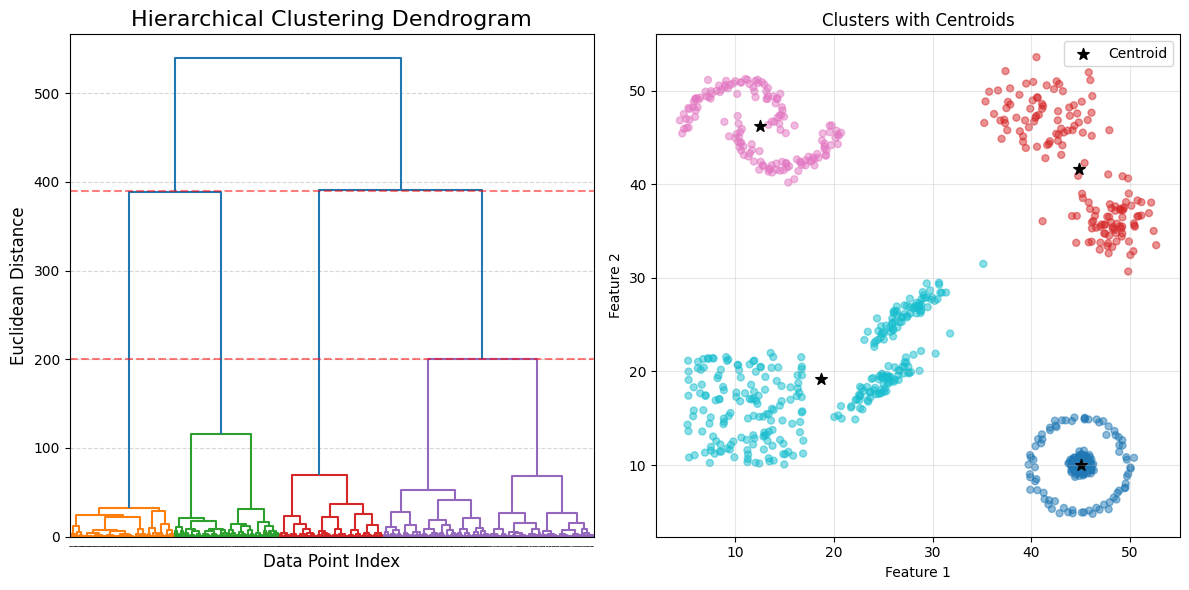

In [17]:
def plot_hierarchical_clusters(data, num_clusters=6, method='ward', metric='euclidean'):

    Z = compute_linkage(data, method=method, metric=metric)
    
    cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')
    df_h = pd.DataFrame(data, columns=[f'feature{i+1}' for i in range(data.shape[1])])
    df_h['cluster'] = cluster_labels
    centroids = df_h.groupby('cluster')[['feature1', 'feature2']].mean().values

    fig, axes = plt.subplots(1, 2, figsize=(12,6))
    
    dendrogram(Z, ax=axes[0], labels=None, leaf_rotation=0, leaf_font_size=0)
    axes[0].set_title("Hierarchical Clustering Dendrogram", fontsize=16)
    axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[0].axhline(y=390, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xlabel("Data Point Index", fontsize=12)
    axes[0].set_ylabel("Euclidean Distance", fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    axes[1].scatter(df_h['feature1'], df_h['feature2'], s=25, alpha=0.5, c=df_h['cluster'], cmap='tab10')
    axes[1].scatter(centroids[:,0], centroids[:,1], c='black', marker='*', s=75, label='Centroid')
    axes[1].set_title("Clusters with Centroids")
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f"../images/synthetic_data/hierarchical_clustering_dendrogram_clusters.png", dpi=300)

    plt.show()
    
    return df_h, Z
df_clusters, Z = plot_hierarchical_clusters(df_h, num_clusters=4)

# DBSCAN

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics

In [20]:
def compute_k_distances(data, min_samples=4):
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(data)
    distances, _ = neighbors_fit.kneighbors(data)
    k_distances = np.sort(distances[:, -1])
    return k_distances

In [21]:
def plot_k_distance(ax, k_distances, min_samples=4, eps_suggested=None):
    ax.plot(k_distances, lw=2, linestyle='--', label=f'{min_samples}-th Nearest Neighbor Distance')
    ax.set_title("DBSCAN k-distance Graph for eps Selection", fontsize=12)
    ax.set_xlabel("Points sorted by distance", fontsize=10)
    ax.set_ylabel(f"{min_samples}-th Nearest Neighbor Distance", fontsize=10)
    ax.grid(alpha=0.3)
    if eps_suggested:
        ax.axhline(y=eps_suggested, color='green', linestyle=':', label=f'Suggested eps ≈ {eps_suggested}')
    ax.legend(fontsize=8)

In [22]:
def plot_dbscan_clusters(ax, df, eps=2, min_samples=4):

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = dbscan.fit_predict(df)

    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    db_sil = silhouette_score(df, db_labels) if n_clusters_db > 1 else np.nan

    print(f"DBSCAN clusters: {n_clusters_db}, silhouette score: {db_sil:.3f}")

    noise_mask = db_labels == -1
    ax.scatter(df.iloc[noise_mask, 0], df.iloc[noise_mask, 1], c='gray', s=25, alpha=0.5, label='Noise')
    ax.scatter(df.iloc[~noise_mask, 0], df.iloc[~noise_mask, 1], c=db_labels[~noise_mask], cmap='tab10', s=25, alpha=0.6)
    
    ax.set_title(f"DBSCAN Clustering (clusters={n_clusters_db})\nSilhouette={db_sil:.2f}", fontsize=12)
    ax.set_xlabel("Feature 1", fontsize=10)
    ax.set_ylabel("Feature 2", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    return db_labels, db_sil, n_clusters_db

DBSCAN clusters: 9, silhouette score: 0.484


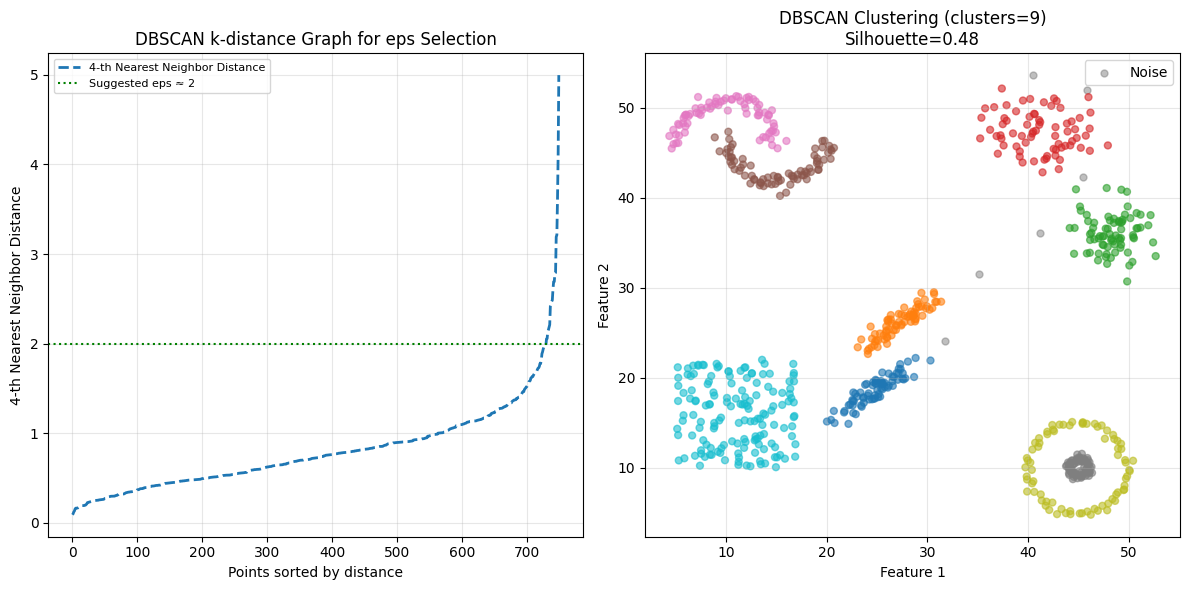

In [23]:
def plot_dbscan_with_kdistance(df, min_samples=4, eps=2, figsize=(12,6)):
    k_distances = compute_k_distances(df, min_samples)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    plot_k_distance(axes[0], k_distances, min_samples, eps_suggested=eps)
    db_labels, db_sil, n_clusters_db = plot_dbscan_clusters(axes[1], df, eps, min_samples)
    
    plt.tight_layout()
    plt.savefig("../images/synthetic_data/dbscan_eps_selection_and_clusters.png", dpi=300)
    plt.show()
    
    return db_labels, db_sil, n_clusters_db

db_labels, db_sil, n_clusters_db = plot_dbscan_with_kdistance(df_h, min_samples=4, eps=2)

# References

- [1 ] *Inspired by the Scikit-learn example on K-Means and silhouette analysis* [Scikit-learn K-Means Silhouette Example](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).
- [2] *Inspired by Scikit-learn examples on K-Means stability* [Scikit-learn K-Means Stability Example](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_stability_low_dim_dense.html).
- [3] [Scikit Learn Clusteirng](https://scikit-learn.org/stable/modules/clustering.html)